In [1]:
# Cell 1: Setup

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import math

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    tf.config.optimizer.set_jit(True)

# Mixed precision: conv/dense ops run in float16, weights stay float32
keras.mixed_precision.set_global_policy('mixed_float16')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Compute dtype: {keras.mixed_precision.global_policy().compute_dtype}")

np.random.seed(42)
tf.random.set_seed(42)

LATENT_DIM  = 64
KL_WEIGHT   = 1.0
BATCH_SIZE  = 256
LEARNING_RATE = 0.003
WEIGHT_DECAY  = 0.0005
CLIPNORM      = 2.0
EPOCHS        = 100

AES_START_EPOCH   = int(EPOCHS * 0.3)
MODEL_START_EPOCH = int(EPOCHS * 0.35)
WARMUP_EPOCHS     = EPOCHS // 20
LR_DECAY_FACTOR   = int(EPOCHS * 0.015)

BASE_FILTERS   = 16
NUM_LAYERS     = 4
BOTTLENECK_DIM = 4

IMAGE_SIZE_X = 32
IMAGE_SIZE_Y = 32
CHANNELS     = 3
STRIDE       = 2

NUM_DOWNSAMP = int(math.log2(IMAGE_SIZE_X // BOTTLENECK_DIM))

2026-04-24 15:36:09.728440: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-24 15:36:10.465593: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-24 15:36:12.953929: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Compute dtype: float16


In [2]:
# Cell 2: Architecture

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = keras.random.normal(shape=keras.ops.shape(z_mean), dtype=z_mean.dtype)
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon


def build_encoder(latent_dim=LATENT_DIM):
    inputs = keras.Input(shape=(IMAGE_SIZE_X, IMAGE_SIZE_Y, CHANNELS))
    x = inputs
    for i in range(NUM_LAYERS):
        filters = BASE_FILTERS * (2 ** i)
        stride  = STRIDE if i < NUM_DOWNSAMP else 1
        x = layers.Conv2D(filters, 3, strides=stride, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.2)(x)
    # dtype='float32' keeps these outputs in full precision under mixed precision
    z_mean    = layers.Dense(latent_dim, name='z_mean',    dtype='float32')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var', dtype='float32')(x)
    z         = Sampling()([z_mean, z_log_var])
    return keras.Model(inputs, [z_mean, z_log_var, z], name='encoder')


def build_decoder(latent_dim=LATENT_DIM):
    inputs        = keras.Input(shape=(latent_dim,))
    final_filters = BASE_FILTERS * (2 ** (NUM_LAYERS - 1))
    x = layers.Dense(BOTTLENECK_DIM * BOTTLENECK_DIM * final_filters, activation='relu')(inputs)
    x = layers.Reshape((BOTTLENECK_DIM, BOTTLENECK_DIM, final_filters))(x)
    for i in range(NUM_LAYERS - 1, -1, -1):
        filters = BASE_FILTERS * (2 ** i)
        stride  = STRIDE if i < NUM_DOWNSAMP else 1
        x = layers.Conv2DTranspose(filters, 3, strides=stride, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
    outputs = layers.Conv2D(CHANNELS, 3, padding='same', activation='tanh', dtype='float32')(x)
    return keras.Model(inputs, outputs, name='decoder')


class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight_var, **kwargs):
        super().__init__(**kwargs)
        self.encoder   = encoder
        self.decoder   = decoder
        self.kl_weight_var = tf.Variable(kl_weight_var, trainable=False, dtype=tf.float32)

        # Metric trackers so val_recon_loss / val_kl_loss appear in logs
        # Averaged over whole epoch too instead of just showing the last batch's recon/kl loss
        self._loss_tracker       = keras.metrics.Mean(name='loss')
        self._recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self._kl_loss_tracker    = keras.metrics.Mean(name='kl_loss')

    @property       # Makes metrics act like a variable so Keras can find and reset them each epoch
    def metrics(self):
        return [self._loss_tracker, self._recon_loss_tracker, self._kl_loss_tracker]

    def call(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        return self.decoder(z)

    def _compute_losses(self, x, reconstruction, z_mean, z_log_var):
        # Cast to float32 as mixed precision can produce float16 tensors
        x              = tf.cast(x,              tf.float32)
        reconstruction = tf.cast(reconstruction, tf.float32)
        z_mean         = tf.cast(z_mean,         tf.float32)
        z_log_var      = tf.cast(z_log_var,      tf.float32)
        recon_loss = tf.reduce_mean(
            tf.reduce_sum(tf.square(x - reconstruction), axis=[1, 2, 3])
        )
        # reduce_sum over axis=1 (latent dims) first, then mean over batch
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = recon_loss + tf.cast(self.kl_weight_var, tf.float32) * kl_loss
        return total_loss, recon_loss, kl_loss

    def _update_metrics(self, total, recon, kl):
        self._loss_tracker.update_state(total)
        self._recon_loss_tracker.update_state(recon)
        self._kl_loss_tracker.update_state(kl)
        return {
            'loss':       self._loss_tracker.result(),
            'recon_loss': self._recon_loss_tracker.result(),
            'kl_loss':    self._kl_loss_tracker.result(),
        }

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x, training=True)
            reconstruction       = self.decoder(z, training=True)
            total, recon, kl     = self._compute_losses(x, reconstruction, z_mean, z_log_var)
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return self._update_metrics(total, recon, kl)

    def test_step(self, data):
        x, _ = data
        z_mean, z_log_var, z = self.encoder(x, training=False)
        reconstruction       = self.decoder(z, training=False)
        total, recon, kl     = self._compute_losses(x, reconstruction, z_mean, z_log_var)
        return self._update_metrics(total, recon, kl)


encoder = build_encoder(latent_dim=LATENT_DIM)
decoder = build_decoder(latent_dim=LATENT_DIM)
vae     = VAE(encoder, decoder, kl_weight_var=KL_WEIGHT, name='vae')
print('VAE built.')

I0000 00:00:1777041375.377442  690903 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


VAE built.


In [ ]:
# Cell 3: Custom Callbacks

# KL annealing: gradually increases KL weight from 0 to target over number of warmup epochs
class KLAnneal(keras.callbacks.Callback):
    def __init__(self, weight_target=KL_WEIGHT, warmup_epochs=WARMUP_EPOCHS, verbose=True):
        super().__init__()
        self.kl_weight_target = weight_target
        self.warmup_epochs    = warmup_epochs
        self.verbose          = verbose

    def on_epoch_end(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            new_weight = (epoch + 1) / self.warmup_epochs * self.kl_weight_target
            self.model.kl_weight_var.assign(new_weight)
            if self.verbose:
                print(f'\n[KL Annealing] Epoch {epoch + 1}: KL weight set to {new_weight:.4f}.')

# Adaptive early stopping: patience shrinks after LR reductions based on their previous value, not absolute thresholds
class AdaptiveEarlyStopping(keras.callbacks.Callback):
    def __init__(self, monitor='val_loss', base_patience=7, min_delta=0.1,
                 patience_decay=0.7, min_patience=3, start_epoch=0,
                 restore_best_weights=True, verbose=True):
        super().__init__()
        self.monitor              = monitor
        self.base_patience        = base_patience
        self.current_patience     = base_patience
        self.min_delta            = min_delta
        self.patience_decay       = patience_decay
        self.min_patience         = min_patience
        self.start_epoch          = start_epoch
        self.restore_best_weights = restore_best_weights
        self.verbose              = verbose
        self.best                 = np.inf
        self.wait                 = 0
        self.best_weights         = None
        self._prev_lr             = None
        self.stopped_epoch        = 0

    def on_train_begin(self, logs=None):
        self.best             = np.inf
        self.wait             = 0
        self.best_weights     = None
        self._prev_lr         = float(keras.backend.get_value(self.model.optimizer.learning_rate))
        self.current_patience = self.base_patience

    def on_epoch_end(self, epoch, logs=None):
        if epoch < self.start_epoch:
            return
        logs    = logs or {}
        current = logs.get(self.monitor)
        if current is None:
            return
        current_lr = float(keras.backend.get_value(self.model.optimizer.learning_rate))
        if self._prev_lr is not None:
            relative_drop = (self._prev_lr - current_lr) / (self._prev_lr + 1e-10)
            if relative_drop > 0.075:
                self.current_patience = max(
                    self.min_patience,
                    int(self.current_patience * self.patience_decay)
                )
                if self.verbose:
                    print(f'\n[AdaptiveES] LR dropped {self._prev_lr:.2e} -> {current_lr:.2e}; patience -> {self.current_patience}')
        self._prev_lr = current_lr
        if current < self.best - self.min_delta:
            self.best         = current
            self.wait         = 0
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.verbose:
                print(f'\n[AdaptiveES] No improvement for {self.wait}/{self.current_patience} epochs (best={self.best:.4f})')
            if self.wait >= self.current_patience:
                self.stopped_epoch          = epoch
                self.model.stop_training    = True
                if self.restore_best_weights and self.best_weights is not None:
                    if self.verbose:
                        print('\n[AdaptiveES] Restoring best weights.')
                    self.model.set_weights(self.best_weights)

# ModelCheckpoint that only starts saving after a certain number of epochs to avoid saving useless checkpoints during early unstable training phases
class DelayedModelCheckpoint(keras.callbacks.ModelCheckpoint):
    def __init__(self, *args, start_epoch=0, **kwargs):
        super().__init__(*args, **kwargs)
        self.start_epoch = start_epoch

    def on_epoch_end(self, epoch, logs=None):
        if epoch < self.start_epoch:
            return
        super().on_epoch_end(epoch, logs)

In [ ]:
# Cell 4: Data Pipeline

(x_train, _), (x_test, _) = keras.datasets.cifar10.load_data()

x_train = (x_train.astype('float32') / 127.5) - 1.0
x_test  = (x_test.astype('float32')  / 127.5) - 1.0

print(f'Training data: {x_train.shape}')
print(f'Test data:     {x_test.shape}')

@tf.function        # Decorator compiles this function into a TensorFlow graph for better performance when used in the data pipeline
def augment(x, y):      # Augmentation function that applies random transformations to the input images to improve generalization. The target (y) is ignored since this is an autoencoder.
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, max_delta=0.1)   # adds richer variety to training images
    x = tf.image.random_contrast(x, lower=0.9, upper=1.1)
    x = tf.clip_by_value(x, -1.0, 1.0)                # keep values in valid [-1, 1] range after augmentation
    return x, x

train_dataset = (
    tf.data.Dataset.from_tensor_slices((x_train, x_train))
    .cache()                          # keeps dataset in RAM after epoch 1
    .shuffle(len(x_train))            # full-dataset shuffle for proper random batches
    .batch(BATCH_SIZE)
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((x_test, x_test))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Cosine-decay LR schedule with linear warm-up
steps_per_epoch = len(x_train) // BATCH_SIZE
total_steps  = steps_per_epoch * EPOCHS
warmup_steps = steps_per_epoch * WARMUP_EPOCHS

lr_schedule = keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=LEARNING_RATE // 10,  # start lower for warm-up
    decay_steps=total_steps * LR_DECAY_FACTOR,  # slow down decay to give AES more time to work
    alpha=1e-6,          # minimum LR at end of cosine decay
    warmup_target=LEARNING_RATE,
    warmup_steps=warmup_steps,
)

# Re-compile with scheduled LR
lr_optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=WEIGHT_DECAY,
    clipnorm=CLIPNORM,
)
vae.compile(optimizer=lr_optimizer)

# Force-build before model checkpoint tries to save, otherwise it breaks
vae(tf.zeros((1, IMAGE_SIZE_X, IMAGE_SIZE_Y, CHANNELS)))
print('Starting training.')

# Callbacks:

print_lr = keras.callbacks.LambdaCallback(
    on_epoch_end=lambda epoch, logs: print(f"\n[Learning Rate: {float(vae.optimizer.learning_rate):.2e}]")
)

kl_anneal = KLAnneal(weight_target=KL_WEIGHT, warmup_epochs=WARMUP_EPOCHS * 2, verbose=True)

adaptive_es = AdaptiveEarlyStopping(
    monitor='val_loss',
    base_patience=EPOCHS // 10,
    min_delta=0.1,
    patience_decay=0.7,
    start_epoch=AES_START_EPOCH,
    restore_best_weights=True,
    verbose=True,
)

checkpoint = DelayedModelCheckpoint(
    'vae_best.weights.h5',
    start_epoch=MODEL_START_EPOCH,
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1,
)

csv_logger = keras.callbacks.CSVLogger('training_log.csv', append=False)

history = vae.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=val_dataset,
    verbose=2,
    callbacks=[print_lr, kl_anneal, adaptive_es, checkpoint, csv_logger],
)

/home/username/tf-env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data: (50000, 32, 32, 3)
Test data:     (10000, 32, 32, 3)


2026-04-24 15:36:32.309354: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-04-24 15:36:32.416016: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


Starting training.
Epoch 1/100


2026-04-24 15:36:42.154907: I external/local_xla/xla/service/service.cc:163] XLA service 0x72fd48004010 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-24 15:36:42.154948: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
I0000 00:00:1777041402.322874  691000 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-04-24 15:36:46.336542: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-24 15:37:06.864345: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3536', 16 bytes spill stores, 16 bytes spill loads




[Learning Rate: 5.97e-04]

[KL Annealing] Epoch 1: KL weight set to 0.1000.
196/196 - 53s - 268ms/step - kl_loss: 666.2733 - loss: 1574.8365 - recon_loss: 908.5630 - val_kl_loss: 8.5108 - val_loss: 725.8976 - val_recon_loss: 717.3868
Epoch 2/100

[Learning Rate: 1.20e-03]

[KL Annealing] Epoch 2: KL weight set to 0.2000.
196/196 - 2s - 12ms/step - kl_loss: 164.8728 - loss: 330.8327 - recon_loss: 314.3455 - val_kl_loss: 141.3991 - val_loss: 278.0656 - val_recon_loss: 263.9257
Epoch 3/100

[Learning Rate: 1.80e-03]

[KL Annealing] Epoch 3: KL weight set to 0.3000.
196/196 - 2s - 11ms/step - kl_loss: 151.3675 - loss: 254.1166 - recon_loss: 223.8432 - val_kl_loss: 170.9104 - val_loss: 284.2462 - val_recon_loss: 250.0641
Epoch 4/100

[Learning Rate: 2.41e-03]

[KL Annealing] Epoch 4: KL weight set to 0.4000.
196/196 - 1s - 6ms/step - kl_loss: 124.8289 - loss: 233.0931 - recon_loss: 195.6445 - val_kl_loss: 142.2136 - val_loss: 256.9700 - val_recon_loss: 214.3059
Epoch 5/100

[Learning Rate:

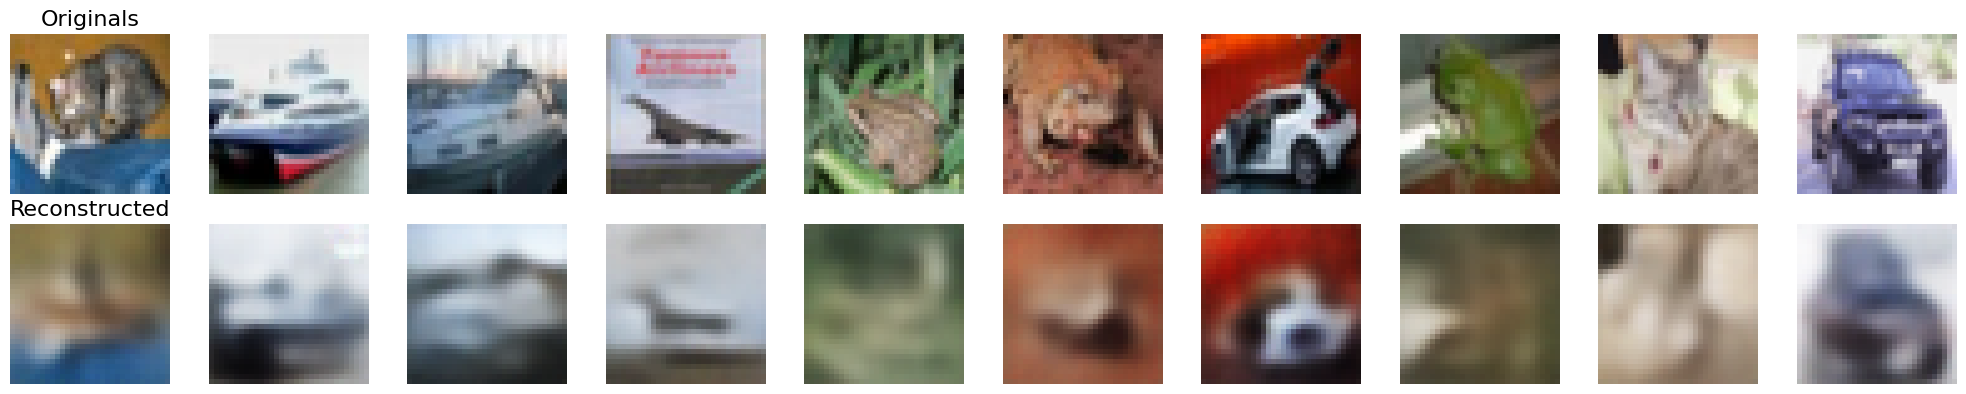

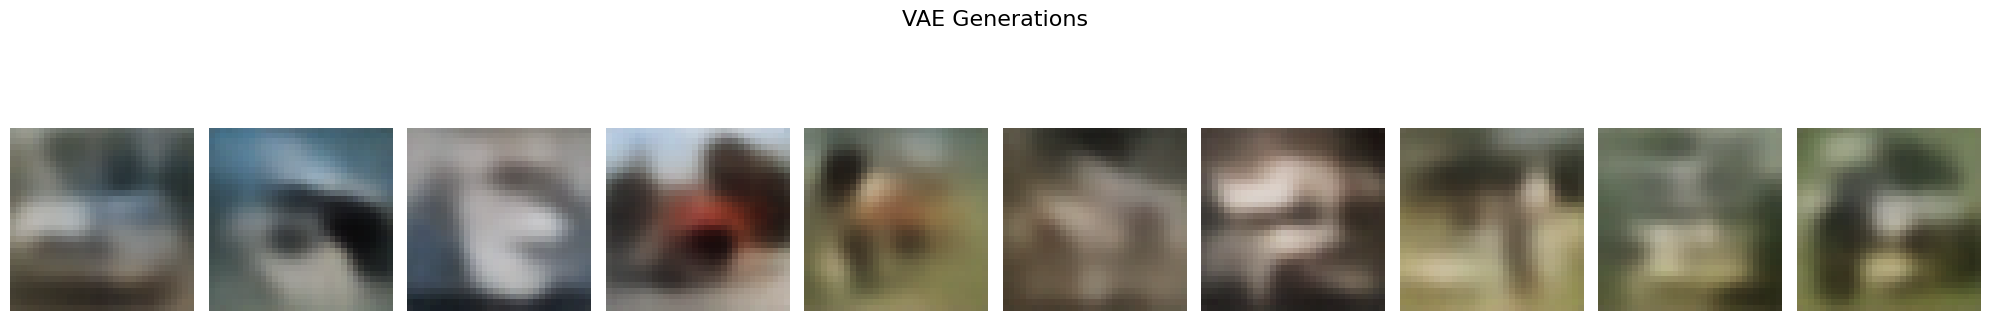

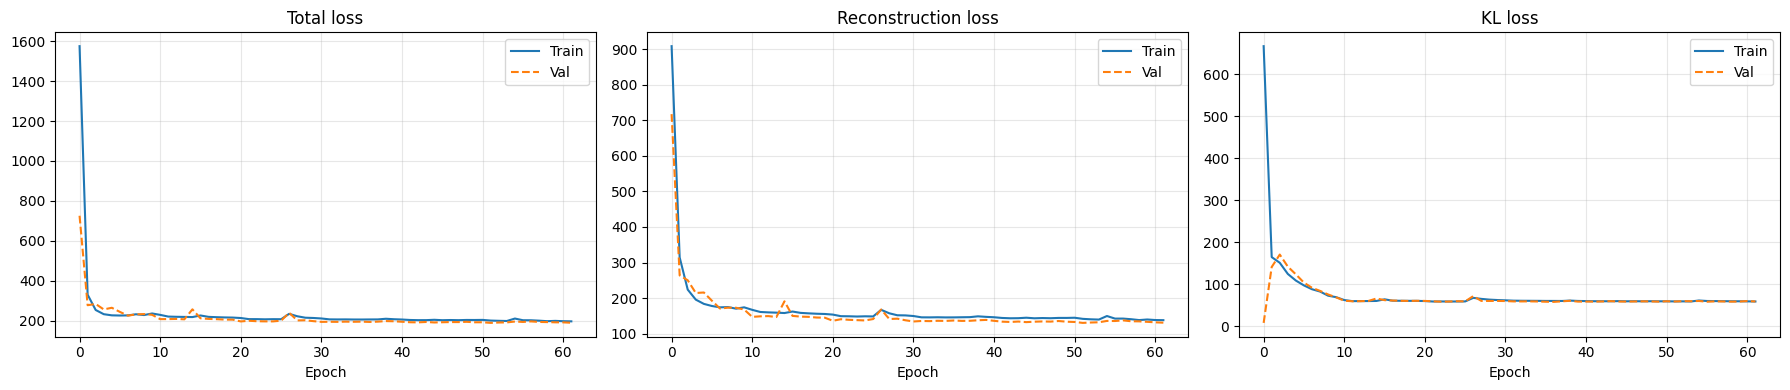

Final train loss : 197.2982
Final val loss   : 190.2295
Final recon loss : 137.9043
Final KL loss    : 59.3939


In [5]:
# Cell 5: Visualisation

# Function to convert tanh outputs back to [0, 1] range for display
def tanh_display(img):
    return (np.clip(img, -1, 1) + 1) / 2

# Reconstructions
test_samples  = x_test[:10]
reconstructed = vae.predict(test_samples, verbose=0)
fig, axes     = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(tanh_display(test_samples[i]))
    axes[0, i].axis('off')
    axes[1, i].imshow(tanh_display(reconstructed[i]))
    axes[1, i].axis('off')
axes[0, 0].set_title('Originals', loc='center', fontsize=16)
axes[1, 0].set_title('Reconstructed', loc='center', fontsize=16)
plt.tight_layout()
plt.show()

# Generations
random_latent = np.random.normal(size=(10, LATENT_DIM))
generated     = decoder.predict(random_latent, verbose=0)
fig, axes     = plt.subplots(1, 10, figsize=(20, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(tanh_display(generated[i]))
    ax.axis('off')
plt.suptitle('VAE Generations', fontsize=16)
plt.tight_layout()
plt.show()

# Loss curves: total, recon, and KL
hist    = history.history
n_plots = 3
fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 4))
panels = [
    ('Total loss',          'loss',       'val_loss'),
    ('Reconstruction loss', 'recon_loss', 'val_recon_loss'),
    ('KL loss',             'kl_loss',    'val_kl_loss'),
]
for ax, (title, train_key, val_key) in zip(axes, panels):
    if train_key in hist:
        ax.plot(hist[train_key], label='Train')
    if val_key in hist:
        ax.plot(hist[val_key], label='Val', linestyle='--')
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss : {hist['loss'][-1]:.4f}")
print(f"Final val loss   : {hist['val_loss'][-1]:.4f}")
if 'recon_loss' in hist:
    print(f"Final recon loss : {hist['recon_loss'][-1]:.4f}")
if 'kl_loss' in hist:
    print(f"Final KL loss    : {hist['kl_loss'][-1]:.4f}")

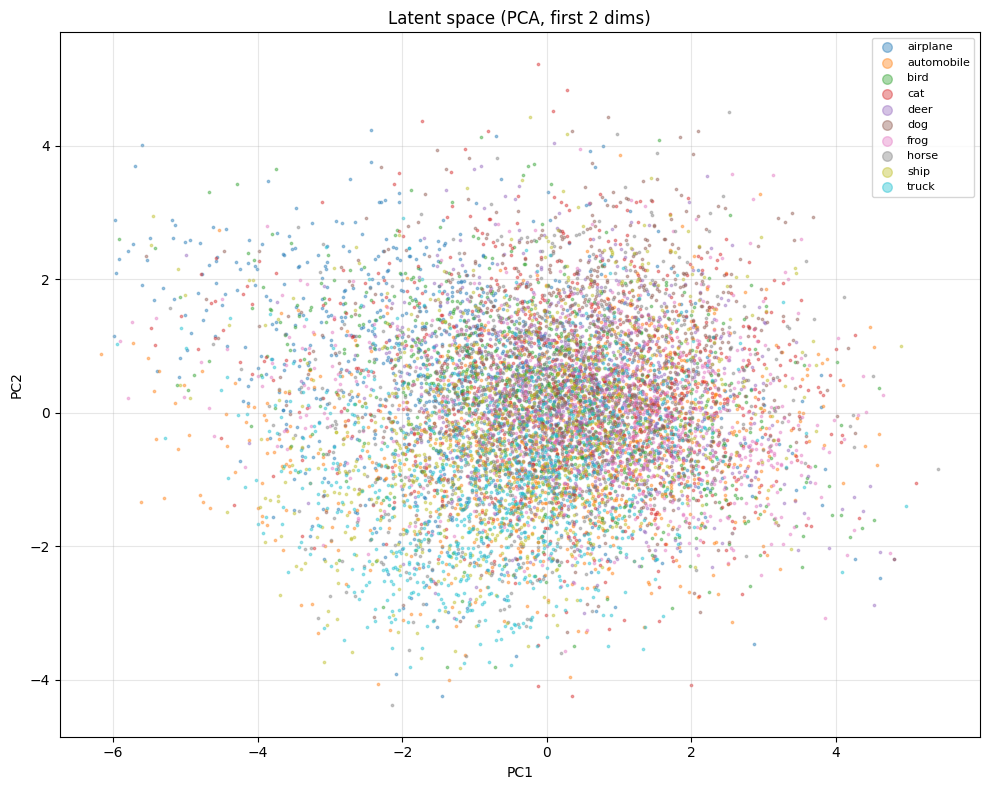

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ ((None, 64), (None,    │       360,672 │
│                                 │ 64), (None, 64))       │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer (InputLayer)   │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d (Conv2D)            │ (None, 16, 16, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization        │ (None, 16, 16, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_1 (Conv2D)          │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_1      │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_2 (Conv2D)          │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_2      │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_3 (Conv2D)          │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_3      │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ flatten (Flatten)          │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dropout (Dropout)          │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z_mean (Dense)             │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z_log_var (Dense)          │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ sampling (Sampling)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Functional)            │ (None, 32, 32, 3)      │       378,979 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_1 (InputLayer) │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dense (Dense)              │ (None, 2048)           │       133,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ reshape (Reshape)          │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ conv2d_transpose           │ (None, 4, 4, 128)      │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ batch_normalization_4      │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,217,038 (8.46 MB)

 Trainable params: 738,691 (2.82 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 1,477,387 (5.64 MB)

In [6]:
# Cell 6: Latent Space Visualisation
# Visualise the first two PCA dimensions of the latent space, coloured by class
# A well-trained VAE should show smooth, overlapping blobs (not tight clusters)

(_, y_test_labels) = keras.datasets.cifar10.load_data()[1]

z_means, _, _ = encoder.predict(x_test, verbose=0)

# Manual PCA using NumPy
z_centred            = z_means - z_means.mean(axis=0)
cov                  = np.cov(z_centred, rowvar=False)
eigenvals, eigenvecs = np.linalg.eigh(cov)
# eigh returns ascending order — take the last 2 (largest variance)
top2                 = eigenvecs[:, -2:][:, ::-1]
z_2d                 = z_centred @ top2

labels = y_test_labels.flatten()

cifar10_classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(10, 8))
for cls in range(10):
    mask = labels == cls
    plt.scatter(z_2d[mask, 0], z_2d[mask, 1], s=3, alpha=0.4, label=cifar10_classes[cls])

plt.title('Latent space (PCA, first 2 dims)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(markerscale=4, loc='best', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

vae.summary(expand_nested=True)